<a href="https://colab.research.google.com/github/ishagt/023326-AI-lab-report-2/blob/main/ML(lab1_023326).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: for data preprocessing import necessary libraries read dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

#Step 2: Import Dataset

In [2]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("bharatnatrayn/movies-dataset-for-feature-extracion-prediction")
print("Path to dataset files:", path)

100%|██████████| 1.05M/1.05M [00:00<00:00, 93.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/bharatnatrayn/movies-dataset-for-feature-extracion-prediction/versions/1


In [3]:
import os
csv_file=os.path.join(path,'movies.csv')
df=pd.read_csv(csv_file)
df.head()

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,(2021),"\nAction, Horror, Thriller",6.1,\nA woman with a mysterious illness is forced ...,\n Director:\nPeter Thorwarth\n| \n Star...,"21,062",121.0,NaN
1,Masters of the Universe: Revelation,(2021– ),"\nAnimation, Action, Adventure",5.0,\nThe war for Eternia begins again in what may...,"\n \n Stars:\nChris Wood, \nSara...","17,870",25.0,NaN
2,The Walking Dead,(2010–2022),"\nDrama, Horror, Thriller",8.2,\nSheriff Deputy Rick Grimes wakes up from a c...,"\n \n Stars:\nAndrew Lincoln, \n...","885,805",44.0,NaN
3,Rick and Morty,(2013– ),"\nAnimation, Adventure, Comedy",9.2,\nAn animated series that follows the exploits...,"\n \n Stars:\nJustin Roiland, \n...","414,849",23.0,NaN
4,Army of Thieves,(2021),"\nAction, Crime, Horror",NaN,"\nA prequel, set before the events of Army of ...",\n Director:\nMatthias Schweighöfer\n| \n ...,NaN,NaN,NaN


In [4]:
df.tail()

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
9994,The Imperfects,(2021– ),"\nAdventure, Drama, Fantasy",NaN,\nAdd a Plot\n,\n \n Stars:\nMorgan Taylor Camp...,NaN,NaN,NaN
9995,Arcane,(2021– ),"\nAnimation, Action, Adventure",NaN,\nAdd a Plot\n,\n,NaN,NaN,NaN
9996,Heart of Invictus,(2022– ),"\nDocumentary, Sport",NaN,\nAdd a Plot\n,\n Director:\nOrlando von Einsiedel\n| \n ...,NaN,NaN,NaN
9997,The Imperfects,(2021– ),"\nAdventure, Drama, Fantasy",NaN,\nAdd a Plot\n,\n Director:\nJovanka Vuckovic\n| \n Sta...,NaN,NaN,NaN
9998,The Imperfects,(2021– ),"\nAdventure, Drama, Fantasy",NaN,\nAdd a Plot\n,\n Director:\nJovanka Vuckovic\n| \n Sta...,NaN,NaN,NaN


#Step 3: Sanity Check

In [5]:

df.shape


(9999, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MOVIES    9999 non-null   object 
 1   YEAR      9355 non-null   object 
 2   GENRE     9919 non-null   object 
 3   RATING    8179 non-null   float64
 4   ONE-LINE  9999 non-null   object 
 5   STARS     9999 non-null   object 
 6   VOTES     8179 non-null   object 
 7   RunTime   7041 non-null   float64
 8   Gross     460 non-null    object 
dtypes: float64(2), object(7)
memory usage: 703.2+ KB


In [7]:
# Removes commas and converts the column to numbers, turning missing values into NaN
df['VOTES'] = df['VOTES'].str.replace(',', '', regex=True).astype(float)

In [8]:
dfc=df.copy()
dfc.describe(include="object")

,MOVIES,YEAR,GENRE,ONE-LINE,STARS,Gross
count,9999,9355,9919,9999,9999,460
unique,6817,438,510,8688,7877,332
top,Bleach: Burîchi,(2020– ),\nComedy,\nAdd a Plot\n,\n,$0.01M
freq,65,892,852,1265,456,22


# Step 4: Exploratory Data analysis (EDA)

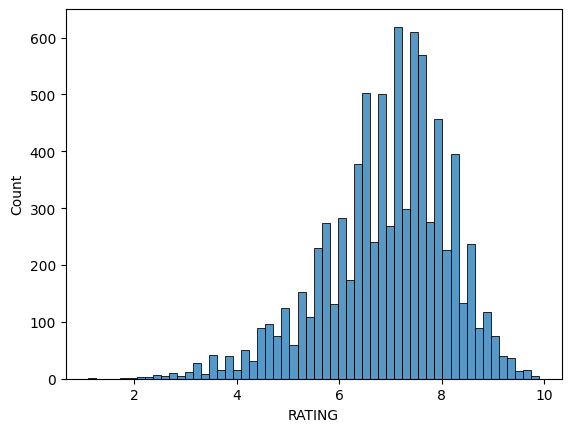

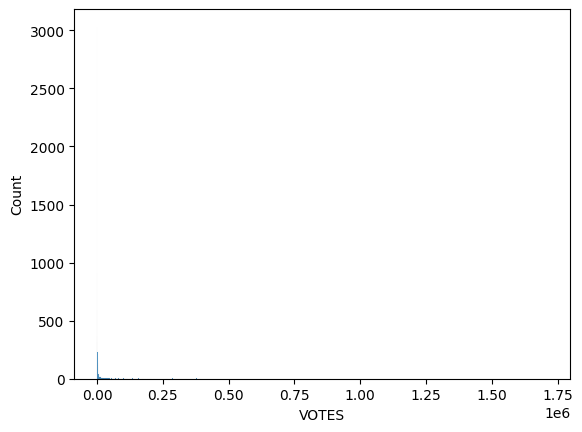

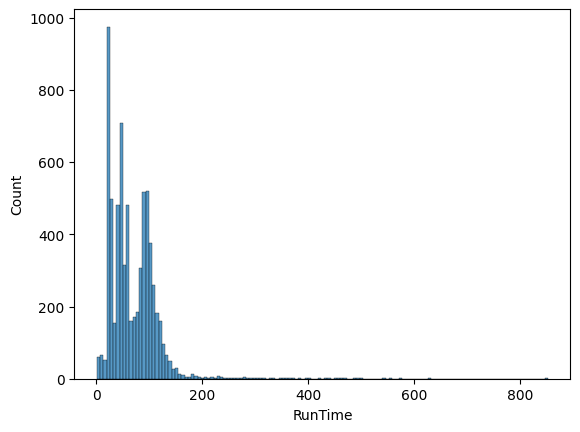

In [9]:
#histogram to understand distribution, histplot for numerical values only

for i in dfc.select_dtypes(include="number").columns:
  sns.histplot(data=dfc, x=i)
  plt.show()


**The first histogram** shows a left-skewed distribution where the vast majority of ratings are positive, mostly clustering between 7.0 and 7.6.

Two Key Takeaways:

Generally High Scores: Low ratings (below 4.0) are very rare; people mostly give above-average scores.

The "Comb" Pattern: The alternating high and low bars show that users prefer rounding their ratings to whole or half numbers (like 7.0, 7.5, 8.0) rather than using precise decimals.

**The second histogram** shows an extremely right-skewed distribution for the VOTES data.

Key Takeaways:

Massive Clumping at Zero: The giant spike on the far left shows that the vast majority of movies or shows have very few votes, close to zero.

Extreme Outliers: There is a tiny, long tail stretching all the way to 1.75 million votes.

The Meaning: This reflects a typical popularity curve—a handful of massive blockbusters get millions of votes, while thousands of lesser-known titles get almost none.

**The third histogram** shows a highly right-skewed (positively skewed), multi-modal distribution of RunTime data.

Key Takeaways:

The Main Clustered Peaks: The vast majority of the data falls under 150 units of time, with distinct, heavy spikes occurring around 20–30, 50, and 90–100 (likely representing standard lengths for TV episodes vs. feature films).

Long Tail / Outliers: There is a very long, sparse tail stretching all the way out past 800. This means while most runtimes are short, there are a few extreme outliers with massive runtimes.

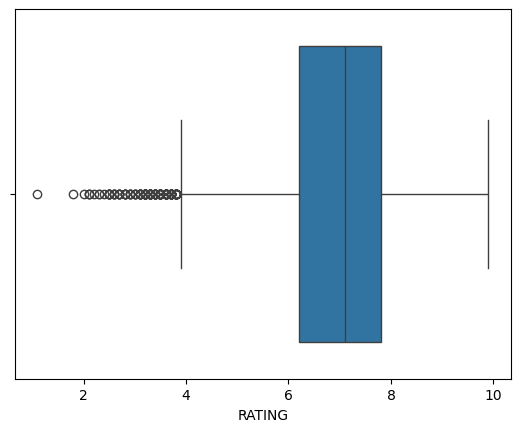

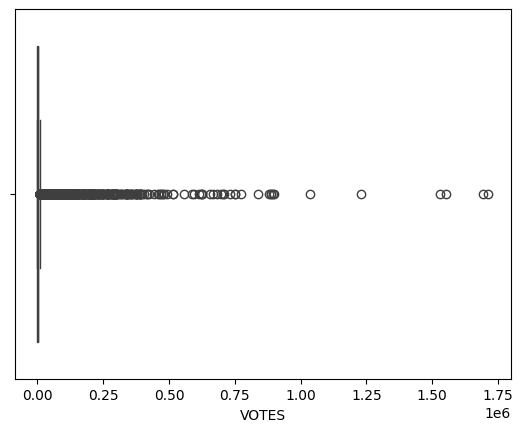

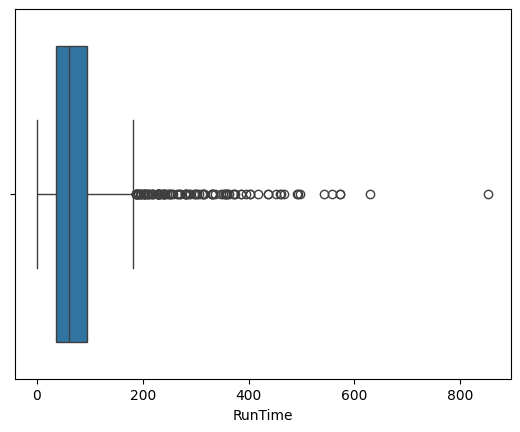

In [10]:
#boxplot to understand distribution to handle outliers

for i in dfc.select_dtypes(include="number").columns: #...dot value are outliers which we have to handle
  sns.boxplot(data=dfc, x=i)
  plt.show()

**The first box plot** shows that the vast majority of ratings are clustered at the higher end of the scale, with a middle (median) rating sitting right around 7.1. The blue box represents the middle 50% of the data, showing that most reviews fall tightly between 6.2 and 7.8. Because the overall data is heavily packed toward these high scores, the straight line on the left sets a boundary near 3.9 for what is considered a normal low rating; anything scoring below this mark is an unusual exception. These exceptionally low reviews are plotted as individual dots stretching down to 1.0, highlighting that while bad ratings do happen, they are rare statistical outliers compared to the generally positive feedback.

**The second box plot** confirms exactly what we saw in the histogram: the VOTES dataset is incredibly packed at the lower end, causing the main "box" and whiskers to be completely flattened against the zero mark on the far left. Because the middle 50% of your data has such low vote counts, the calculated boundary for a normal high value is very small. As a result, every single blockbuster movie that managed to get a significant audience is flagged as an extreme statistical anomaly, creating that massive, dense trail of individual outlier dots stretching all the way out to 1.75 million votes. It perfectly visualizes how a tiny fraction of highly popular titles completely dominates the scale compared to the thousands of low-profile ones.

**The third box plot** summarizes the RunTime data, showing that the vast majority of items have very short durations, with a middle (median) value sitting right around 60 units. The blue box indicates that the middle 50% of all runtimes are tightly packed together, mostly falling between roughly 35 and 95 units. Because the core data is concentrated at these lower numbers, any runtime exceeding approximately 180 units is flagged as an unusual exception. These exceptionally long runtimes are plotted as individual outlier dots that form a very long trail extending far out to the right, with a few extreme entries stretching all the way past 600 and 800 units.

In [11]:
dfc.select_dtypes(include="number").columns
#dfc.select_dtypes(include="object").columns  #for objects

Index(['RATING', 'VOTES', 'RunTime'], dtype='object')

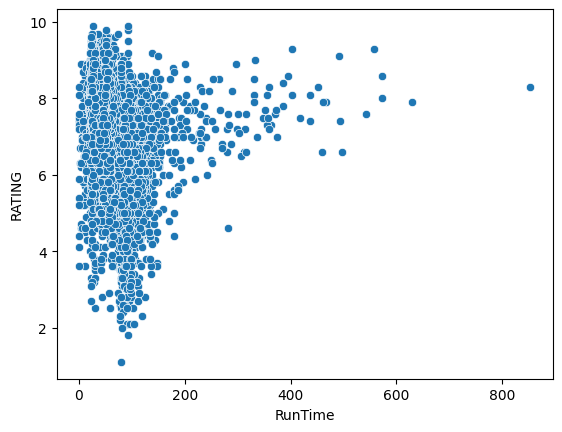

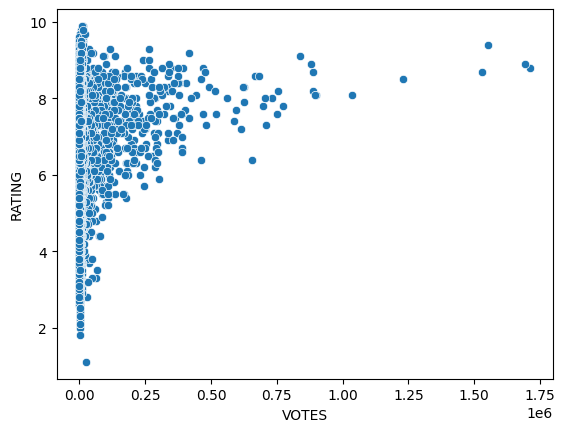

In [12]:
for i in ['RunTime', 'VOTES']:
   sns.scatterplot(data=dfc, x=i, y='RATING')
   plt.show()

**The first scatter plot** shows the relationship between RunTime and RATING, revealing that while most data points are densely packed under 150 minutes with ratings varying wildly from 2.0 to 10.0, a distinct "funnel effect" appears as runtime increases. For exceptionally long media extending past 200 to 400 minutes, the lower ratings completely disappear, and the data points compress into a higher, more consistent bracket between 6.0 and 9.0. This indicates a slight positive trend where longer runtimes are heavily associated with higher, more favorable audience ratings.

**The second scatter plot** reveals a distinct funnel effect between popularity and reception, showing that while titles with very few votes on the far left have highly volatile ratings spanning from 1.0 to 10.0, this variance completely disappears as the vote count increases. For the massive blockbusters stretching out to 1.75 million votes, the lower ratings vanish entirely, and the data points compress into a tight, highly positive bracket between 8.0 and 10.0. This demonstrates a clear trend where any media that manages to secure a massive, mainstream voting audience is almost guaranteed to have a high, widely praised rating.

<Axes: >

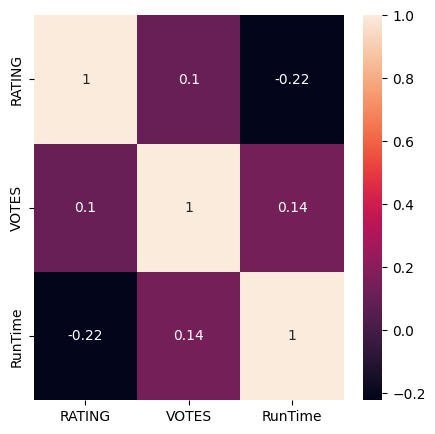

In [13]:
#correlation with heatmap
selected_data=dfc.select_dtypes(include="number").corr()
plt.figure(figsize=(5,5))
sns.heatmap(selected_data,annot=True)


This heatmap displays the linear correlation coefficients between your numeric variables, where a value close to 1 means a strong positive relationship, -1 means a strong negative relationship, and 0 means no relationship. First, the diagonal of 1s simply shows that every variable matches perfectly with itself. More importantly, VOTES and RATING show a very weak positive correlation (0.1), mathematically reflecting that while massive blockbusters stay highly rated, the vast sea of unpopular titles completely dilutes the overall trend. Meanwhile, RunTime and RATING have a weak negative correlation (-0.22), which reveals a slight general tendency where excessively long runtimes can drag down audience scores, despite a few long-form standouts.

#Step 5: Missing Value Treatment


In [14]:
dfc.isnull().sum()

,0
MOVIES,0
YEAR,644
GENRE,80
RATING,1820
ONE-LINE,0
STARS,0
VOTES,1820
RunTime,2958
Gross,9539


In [15]:
for i in ["YEAR","VOTES","Gross"]:
  if pd.api.types.is_numeric_dtype(dfc[i]):
    # For numeric columns, fill with median
    dfc[i] = dfc[i].fillna(dfc[i].median())
  else:
    # For non-numeric (object) columns, fill with mode
    # .mode()[0] is used to get the first mode in case of multiple modes
    dfc[i] = dfc[i].fillna(dfc[i].mode()[0])

In [16]:
dfc.isnull().sum()

,0
MOVIES,0
YEAR,0
GENRE,80
RATING,1820
ONE-LINE,0
STARS,0
VOTES,0
RunTime,2958
Gross,0


In [17]:
from sklearn.impute import KNNImputer
imputer=KNNImputer()

In [18]:
for i in dfc.select_dtypes(include="number").columns:
  dfc[i]=imputer.fit_transform(dfc[[i]])
  dfc['GENRE'] = dfc['GENRE'].fillna(dfc['GENRE'].mode()[0])

In [19]:
dfc.isnull().sum()

,0
MOVIES,0
YEAR,0
GENRE,0
RATING,0
ONE-LINE,0
STARS,0
VOTES,0
RunTime,0
Gross,0


#Ranking feature vectores based on corr

In [21]:
corr_matrix = dfc.corr(numeric_only=True)
target_corr = corr_matrix['RATING']
ranked_corr = target_corr.sort_values(ascending=False)
print(ranked_corr)

RATING     1.000000
VOTES      0.103043
RunTime   -0.205952
Name: RATING, dtype: float64


In [23]:
dfc_subset = dfc[["RATING", "VOTES"]]
dfc_subset.head()

,RATING,VOTES
0,6.100000,21062.0
1,5.000000,17870.0
2,8.200000,885805.0
3,9.200000,414849.0
4,6.921176,789.0


# Step 6: Train Test Split

In [25]:
from sklearn.model_selection import train_test_split
# Features (input variables)
X = dfc_subset.drop(columns=["RATING"])
# Target variable
y = dfc_subset["RATING"]
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(7999, 1)
(2000, 1)
(7999,)
(2000,)


#Step 7: Simple Linear Regression

In [26]:
import numpy as np
# Convert training data to numpy arrays
x = X_train.values.flatten()
y = y_train.values.flatten()
# Number of observations
n = len(x)
# Required summations
sum_x = np.sum(x)
sum_y = np.sum(y)
sum_xy = np.sum(x * y)
sum_x2 = np.sum(x ** 2)
# Calculate b1 (slope)
b1 = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - (sum_x ** 2))
# Calculate b0 (intercept)
b0 = (sum_y * sum_x2 - sum_x * sum_xy) / (n * sum_x2 - (sum_x ** 2))
# Print coefficients
print("Slope (b1):", b1)
print("Intercept (b0):", b0)
# Regression equation
print(f"Regression Equation: y = {b0:.2f} + {b1:.2f}x")

Slope (b1): 1.7083956117649596e-06
Intercept (b0): 6.902291236502583
Regression Equation: y = 6.90 + 0.00x


#Step 8: Error Calculation, RSE calculation

In [28]:
import numpy as np
import pandas as pd

# RSE function (written in the same form as MAE)
def RSE(y_actual, y_predicted):
    # For simple linear regression (1 predictor), degrees of freedom = n - 2
    deg_of_freedom = len(y_actual) - 2
    rss = np.sum((y_actual - y_predicted) ** 2)
    return np.sqrt(rss / deg_of_freedom)

# Convert X_test to 1D array
x_test = X_test.values.flatten()

# Predicted values for all test values x_test
Yp = b0 + b1 * x_test

# Create comparison table
results = pd.DataFrame({"Actual_Y": y_test.values, "Predicted_Y": Yp})

# Calculate individual row errors (residuals)
results["Error"] = results["Actual_Y"] - results["Predicted_Y"]

# Display first rows
print("--- Comparison Table ---")
print(results.head())
print("-" * 24)
# Calculate final metrics using the functions
rse_score = RSE(results["Actual_Y"], results["Predicted_Y"])

print(f"Final RSE: {rse_score:.4f}")

--- Comparison Table ---
   Actual_Y  Predicted_Y     Error
0       6.5     6.902966 -0.402966
1       6.3     6.902351 -0.602351
2       8.9     6.903796  1.996204
3       7.8     6.902327  0.897673
4       6.7     6.903267 -0.203267
------------------------
Final RSE: 1.1241


$$RSE = \sqrt{\frac{\sum (y_i - \hat{y}_i)^2}{n - p}}$$

On average, model's predictions (Predicted_Y (Rating)) miss the actual data points (Actual_Y/ Rating) by about 1.12 units.